Epoch 0 [G loss: 0.7003]


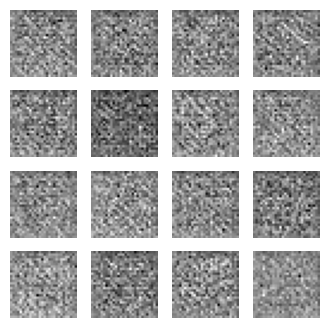

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Flatten
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input

(X_train, _), (_,_)=mnist.load_data()
X_train = (X_train - 127.5)/127.5
X_train = X_train.reshape(X_train.shape[0], 28,28,1)

def build_generator():
    model = Sequential()
    model.add(Input(shape=(100,)))
    model.add(Dense(128 * 7 * 7))
    model.add(LeakyReLU(0.2))
    model.add(Reshape((7, 7, 128)))
    model.add(Conv2DTranspose(128, 4, strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))
    model.add(Conv2DTranspose(64, 4, strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))
    model.add(Conv2D(1, 7, activation='tanh', padding='same'))
    return model

def build_discriminator():
    model = Sequential()
    model.add(Input(shape=(28,28,1)))
    model.add(Conv2D(64, 3, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.))
    model.add(Conv2D(128, 3, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    return model

# Build discriminator
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy',
                      optimizer=Adam(0.0001, 0.5),
                      metrics=['accuracy'])

# Build generator
generator = build_generator()

# Freeze discriminator for GAN
discriminator.trainable = False

# Build GAN
gan = Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy',
            optimizer=Adam(0.0001, 0.5))

def train(epochs=5000, batch_size=64):
    half_batch = batch_size // 2
    for epoch in range(epochs):
        # Train Discriminator
        discriminator.trainable = True
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_imgs = X_train[idx]
        noise = np.random.normal(0, 1, (half_batch, 100))
        fake_imgs = generator.predict(noise, verbose=0)
        # Label smoothing + noise
        real_labels = np.ones((half_batch,1)) * 0.9
        fake_labels = np.zeros((half_batch,1))
        real_labels += 0.05 * np.random.random(real_labels.shape)
        fake_labels += 0.05 * np.random.random(fake_labels.shape)
        # Train discriminator LESS (important)
        if epoch % 2 == 0:
            d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
            d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
        # Train Generator
        discriminator.trainable = False
        noise = np.random.normal(0, 1, (batch_size, 100))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))
        # Print progress
        if epoch % 1000 == 0:
            print(f"Epoch {epoch} [G loss: {g_loss:.4f}]")
            save_images(epoch)

def save_images(epoch):
    noise = np.random.normal(0, 1, (16, 100))
    gen_imgs = generator.predict(noise, verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5
    plt.figure(figsize=(4,4))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow(gen_imgs[i,:,:,0], cmap='gray')
        plt.axis('off')
    plt.show()

train(epochs=5000)
